In [1]:
import os
import tarfile
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [8]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"

In [9]:
extraction_path = "."
archive_path = os.path.join(extraction_path, os.path.basename(url))

urlretrieve(url, archive_path)

with tarfile.open(archive_path, "r") as archive:
    archive.extractall(path=extraction_path)

print(f"Files extracted to: {extraction_path}")

Files extracted to: .


In [10]:
dir_non_agri = "images_dataSAT/class_0_non_agri"
dir_agri = "images_dataSAT/class_1_agri"

## Get the paths of all non-agricultural images.

In [11]:
non_agri_paths = sorted(os.path.join(dir_non_agri, filename)for filename in os.listdir(dir_non_agri))

## Open and display the first image.

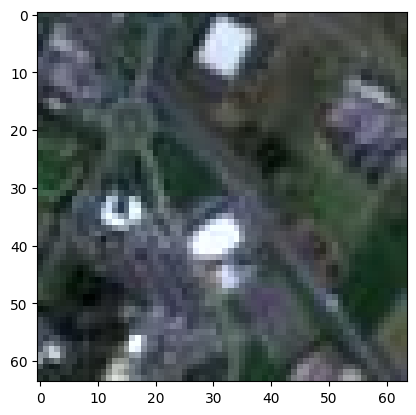

In [12]:
image = Image.open(non_agri_paths[0])

plt.imshow(image)
plt.show()

## Open and display the 4 images.

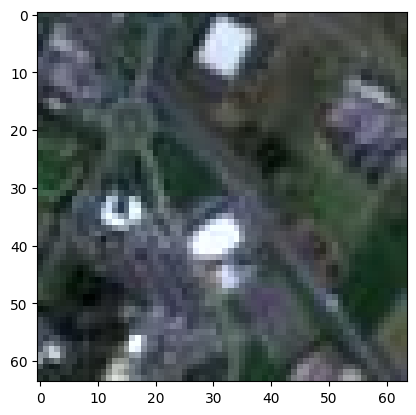

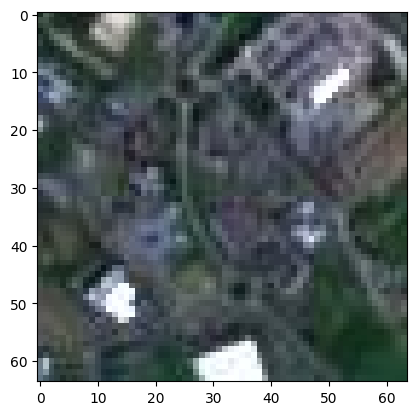

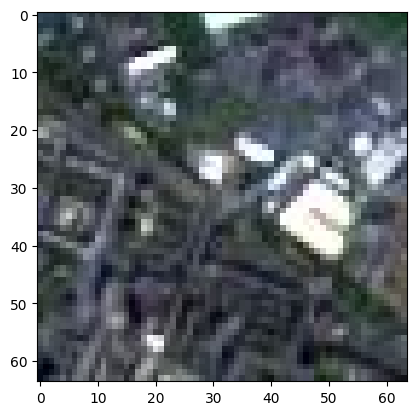

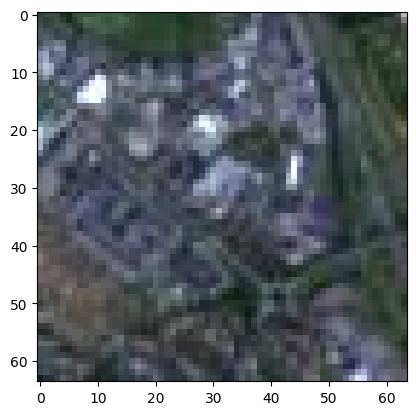

In [13]:
for path in non_agri_paths[:4]:
    plt.imshow(Image.open(path))
    plt.show()

## Count the non-agricultural images.

In [14]:
print(len(non_agri_paths))

3000


## Why use paths instead of loading every image?

A path-based workflow keeps only the current batch in memory:

```text
Image path -> open one batch -> train -> open the next batch

## Create image paths and labels

Each image path is paired with its class label:

| Folder | Label |
| --- | ---: |
| `class_0_non_agri` | 0 |
| `class_1_agri` | 1 |

**Why:** Supervised learning requires both an input image and the correct answer for that image.

In [15]:
base_dir = "./images_dataSAT"

dir_non_agri = base_dir + "/class_0_non_agri"
dir_agri = base_dir + "/class_1_agri"

## You now have two corresponding lists:

- all_image_paths → [image1, image2, image3, ...]
- all_labels      → [0,      0,      1,      ...]

### The positions must always match.

In [16]:
all_image_paths = []
all_labels = []

for filename in sorted(os.listdir(dir_non_agri)):
    all_image_paths.append(os.path.join(dir_non_agri, filename))
    all_labels.append(0)

for filename in sorted(os.listdir(dir_agri)):
    all_image_paths.append(os.path.join(dir_agri, filename))
    all_labels.append(1)

## Shuffle paths and labels together

`zip()` creates pairs such as `(image_path, label)`. Shuffling the pairs changes their order while keeping every image matched to its correct label.

**Why:** A mixed order prevents the model from seeing all images of one class before all images of the other class.

In [17]:
data = list(zip(all_image_paths, all_labels))

np.random.shuffle(data)

all_image_paths, all_labels = zip(*data)

## Create a batch generator

The generator opens and processes a small batch only when the model requests it. This avoids loading the entire image collection into memory at once.

```text
paths -> load a batch -> train -> load the next batch

In [18]:
def generator(paths, labels, batch_size=8):

    while True:
        images = []
        batch_labels = []

        for path, label in zip(paths, labels):

            img = tf.keras.utils.load_img(
                path,
                target_size=(64, 64)
            )

            img = tf.keras.utils.img_to_array(img)

            images.append(img)
            batch_labels.append(label)

            if len(images) == batch_size:
                yield (
                    np.array(images) / 255.0,
                    np.array(batch_labels)
                )

                images = []
                batch_labels = []

## This creates the generator and requests the first batch.

Conceptually:

Dataset
   ↓
Generator
   ↓
8 images
   +
8 labels

In [19]:
import tensorflow as tf
batch_size = 8

data_generator = generator(
    all_image_paths,
    all_labels,
    batch_size=batch_size,
)

images, labels = next(data_generator)

- 8     = batch size
- 64    = image height
- 64    = image width
- 3     = RGB channels

In [20]:
print(images.shape)
print(labels.shape)

(8, 64, 64, 3)
(8,)


#### This displays one image from the batch and its label.

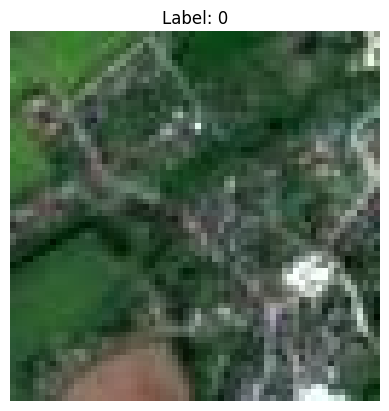

In [21]:
sample_index = 0

plt.imshow(images[sample_index])

plt.title(f"Label: {int(labels[sample_index])}")

plt.axis("off")
plt.show()

## Use Keras for directory-based loading

Keras can infer class labels from folder names and create batched datasets for us. This is simpler and less error-prone than maintaining a custom generator.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels="inferred", #means Keras determines the labels from the folder structure.
    label_mode="int",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=(64, 64),
    batch_size=8,
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


### This creates the validation dataset.

In [23]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=(64, 64),
    batch_size=8,
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


### Augmentation creates additional variations so the CNN can learn patterns that are less sensitive to orientation.
- RandomFlip
- RandomRotation
## Apply augmentation to training batches

The images are randomly flipped or rotated while their labels stay unchanged.

**Why:** These transformations create realistic variation without changing whether an image is agricultural or non-agricultural.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal_and_vertical"
    ),
    tf.keras.layers.RandomRotation(0.2),
])

## Notice:

- x → transformed
- y → unchanged

That's important because the transformation doesn't change the class.

In [25]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True),y))

## Cache the processed training data

Caching keeps processed batches available for later epochs, reducing repeated disk reads.

**Why:** This can speed up training when the dataset fits comfortably in memory. For large datasets, omit caching to avoid excessive RAM usage.

In [26]:
train_ds = train_ds.cache()

## prefetch() helps prepare future batches while the current batch is being processed.

## Conceptually:

CPU → prepare next batch
          ↓
GPU/CPU → train current batch

In [27]:
AUTOTUNE = tf.data.AUTOTUNEtrain_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

NameError: name 'AUTOTUNE' is not defined